## Lab 5.2: Feature Matching

In [32]:
!wget -nc -q -O slo3.jpeg "https://www.dropbox.com/scl/fi/q7utqm075b302qx0psnl7/slo3.jpeg?rlkey=ynepir7gezn6iozmqwuog0d56&dl=1"
!wget -nc -q -O slo4.jpeg "https://www.dropbox.com/scl/fi/zoffc7k5n90tbwts7l4au/slo4.jpeg?rlkey=ivaeckygwy0ddxijmugyrbzxr&dl=1"
!wget -nc -q -O stereo.jpg "https://www.dropbox.com/scl/fi/2r3vy3pc6gm8b3idel66r/stereo.jpg?rlkey=9njsggwjt671orpy32doy7uve&dl=1"

1. Load images ```slo3.jpeg``` and ```slo4.jpeg``` and convert to grayscale.  Detect and match SIFT features between them and plot the results.

Try different settings for ```max_ratio``` to see which seems to produce the best set of matches.

*Note: Set ```only_matches=True``` for ```plot_matched_features``` so that the keypoints don't obscure the images.*

In [33]:
import matplotlib.pyplot as plt
import numpy as np

from imageio.v3 import imread, imwrite
from skimage import data
from skimage import transform
from skimage.color import rgb2gray
from skimage.feature import match_descriptors, plot_matched_features, SIFT

In [34]:
def get_key_and_desc(sift, img):
  sift.detect_and_extract(img)
  keypoints = sift.keypoints
  descriptors = sift.descriptors

  return keypoints, descriptors

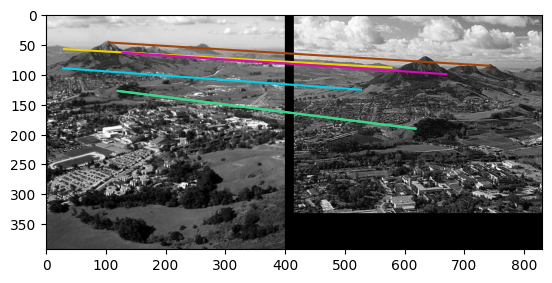

In [35]:
SLO_MAX_RATIO = 0.6

slo3 = rgb2gray(imread("slo3.jpeg"))
slo4 = rgb2gray(imread("slo4.jpeg"))

# Load a sift model
descriptor_extractor = SIFT()

# Get keypoints and descriptors for each image
key3, desc3 = get_key_and_desc(descriptor_extractor, slo3)
key4, desc4 = get_key_and_desc(descriptor_extractor, slo4)

# Get the matches between the images
matches = match_descriptors(desc3, desc4,
                            max_ratio=SLO_MAX_RATIO,
                            cross_check=True)

fig,ax = plt.subplots()
plot_matched_features(slo3, slo4,
                      only_matches=True,
                      keypoints0=key3, keypoints1=key4,
                      matches=matches,
                      ax=ax)


2. The image ```stereo.jpg``` contains a stereo pair image of an asteroid ([Bennu](https://www.asteroidmission.org/candidate-sample-sites/kingfisher/stereopair_kingfisher/)).  Load the image and split it into two images (```left``` and ```right```).  

Detect and match SIFT features between the two images and show the results.

In a rectified stereo pair, the movement between the images should be completely horizontal.  Filter out any matches that have vertical movement and show the results.

*Note: because there are a lot of matches, you might want to show only 10% or so of them.*

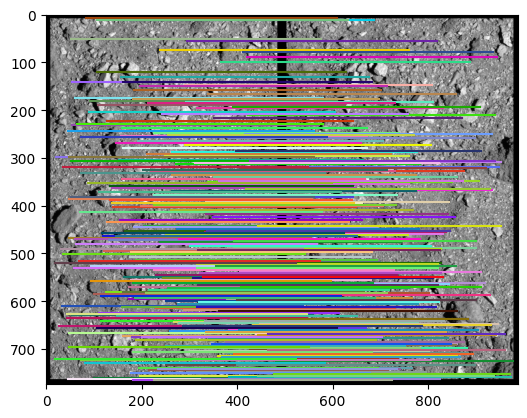

In [36]:
ASTER_MAX_RATIO = 0.9

stereo = rgb2gray(imread("stereo.jpg"))
height, width = stereo.shape[:2]
mid_width = width // 2
left = stereo[:, :mid_width]
right = stereo[:, mid_width:]

# Load a sift model
descriptor_extractor = SIFT()

# Get keypoints and descriptors for each image
key_left, desc_left = get_key_and_desc(descriptor_extractor, left)
key_right, desc_right = get_key_and_desc(descriptor_extractor, right)

# Get the matches between the images
matches = match_descriptors(desc_left, desc_right,
                            max_ratio=ASTER_MAX_RATIO,
                            cross_check=True)

# Filter any lines that are not horizontal
left_indices = matches[:, 0]          # Get indexes for left and right matches
right_indices = matches[:, 1]
left_y = key_left[left_indices, 0]    # Get the y values of each one
right_y = key_right[right_indices, 0]

mask = left_y == right_y              # Make a mask out of those values
filtered_matches = matches[mask]      # Filter the matches based on that mask

fig,ax = plt.subplots()
plot_matched_features(left, right,
                      only_matches=True,
                      keypoints0=key_left, keypoints1=key_right,
                      matches=filtered_matches[::10],
                      ax=ax)
